In [1]:
from google.colab import files


uploaded = files.upload()

Saving step 1.csv to step 1.csv


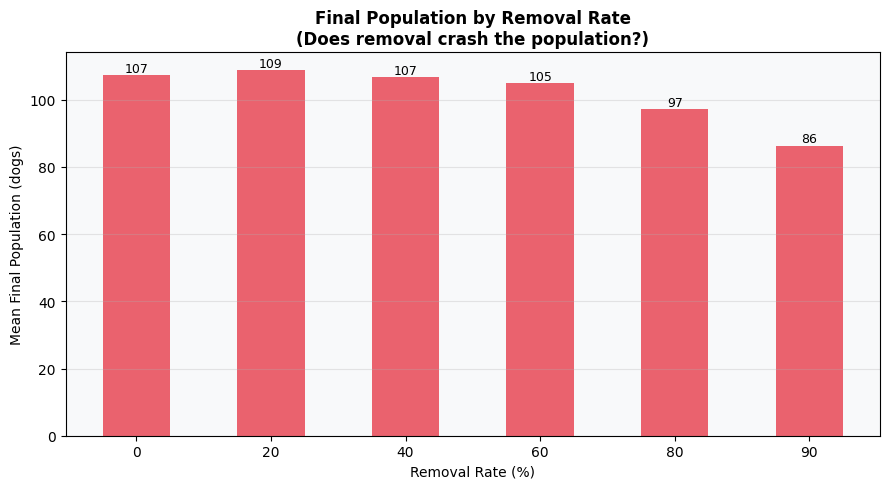

/tmp/ipykernel_945/2363615340.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop_rate = df.groupby('removal-rate').apply(


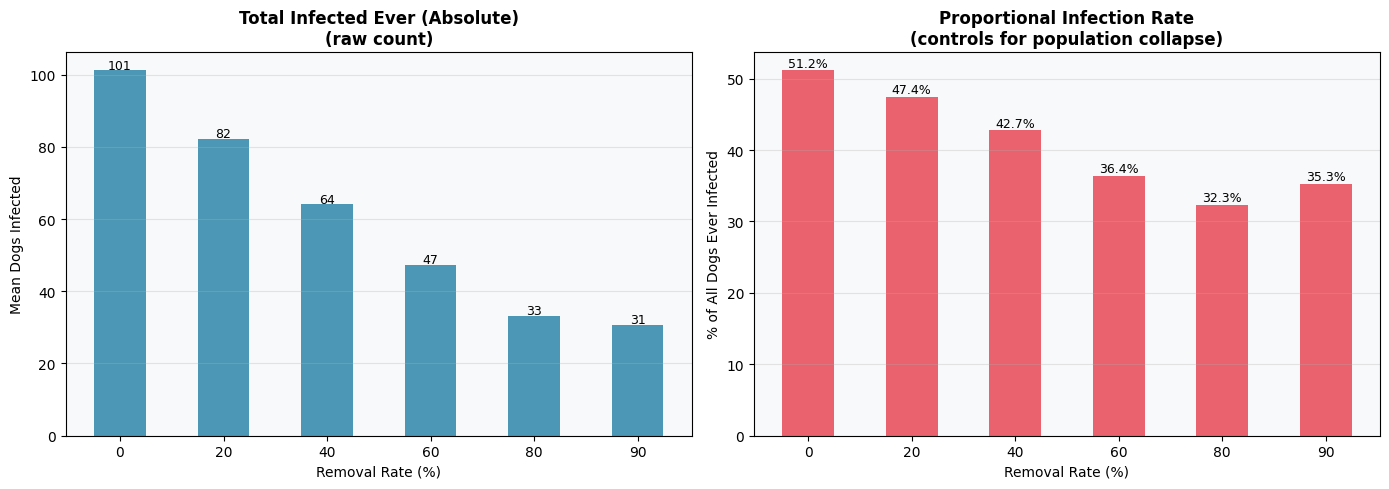

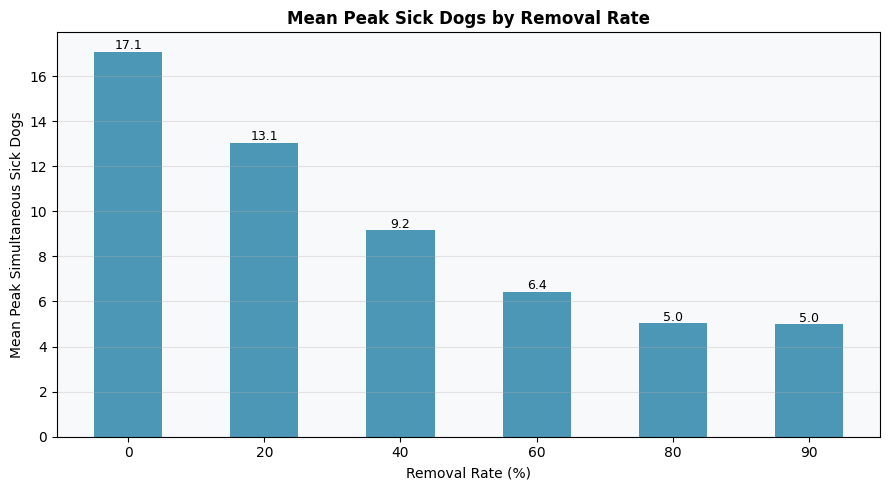

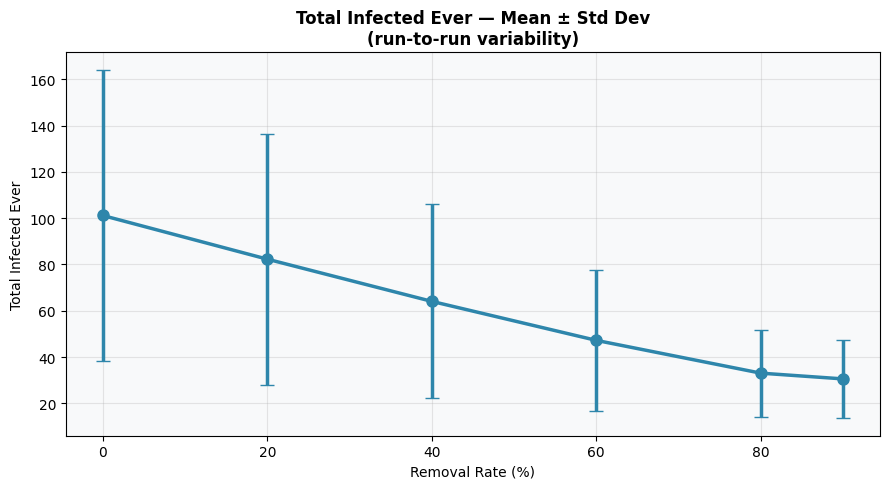

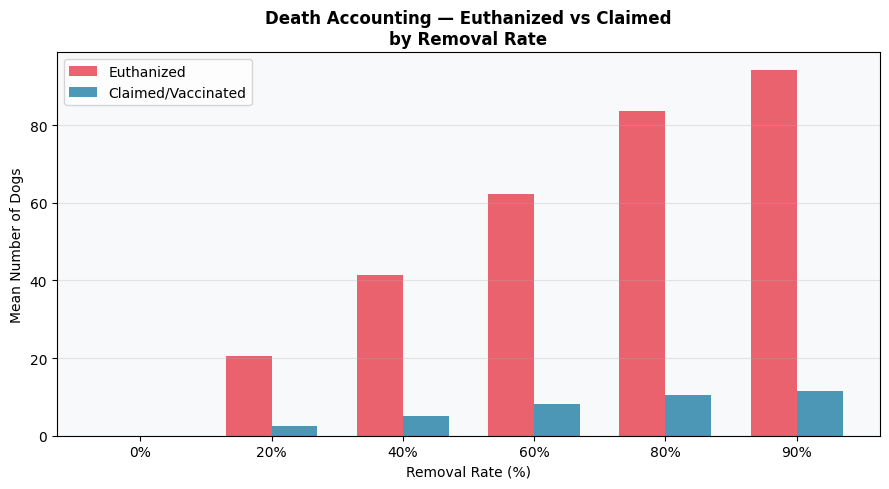

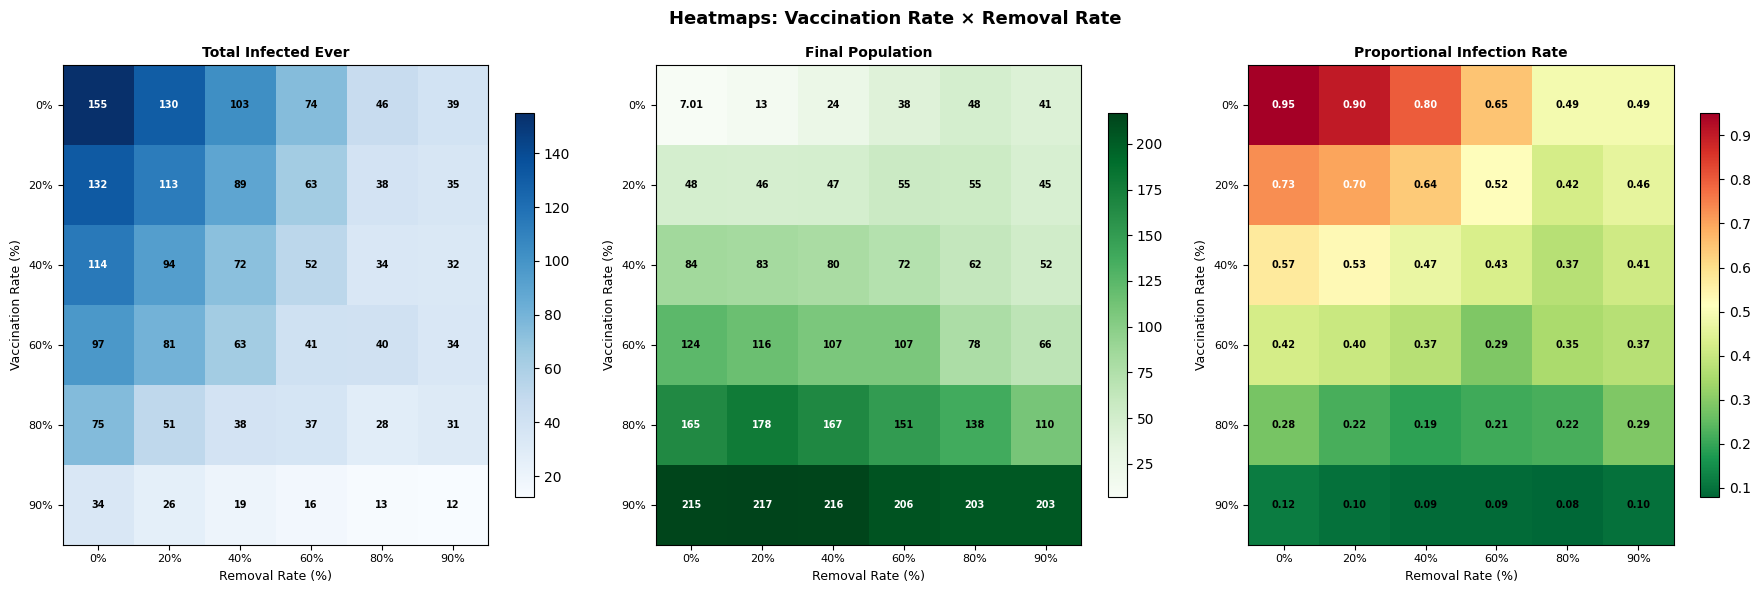


All figures saved!
pop_by_removal.png
raw_vs_rate_comparison.png
peak_infection_rate_by_removal.png
variance_check.png
death_accounting.png
heatmaps_vax_removal.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('step 1.csv')

# Derived metrics
df['infection_rate'] = (
    df['count turtles with [ sick? ]'] / df['count turtles']
).fillna(0)

df['exposed_rate'] = (
    df['count turtles with [ exposed? ]'] / df['count turtles']
).fillna(0)

C_VAC  = '#2E86AB'
C_CULL = '#E84855'
C_BG   = '#F8F9FA'
C_DARK = '#1A1A2E'

# ── FIGURE 1 — Final population by removal rate ──
fig1, ax1 = plt.subplots(figsize=(9, 5), facecolor='white')
pop_summary = df.groupby('removal-rate')['count turtles'].mean()
bars = ax1.bar(pop_summary.index.astype(str), pop_summary.values,
               color=C_CULL, alpha=0.85, width=0.5)
for bar, val in zip(bars, pop_summary.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f'{val:.0f}',
             ha='center', fontsize=9)
ax1.set_title('Final Population by Removal Rate\n(Does removal crash the population?)',
              fontweight='bold')
ax1.set_xlabel('Removal Rate (%)')
ax1.set_ylabel('Mean Final Population (dogs)')
ax1.set_facecolor(C_BG)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pop_by_removal.png', dpi=150)
plt.show()

# ── FIGURE 2 — Raw total infected vs proportional rate ──
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

total_inf = df.groupby('removal-rate')['total-infected-ever'].mean()
prop_rate = df.groupby('removal-rate').apply(
    lambda x: (x['total-infected-ever'] /
               (x['count turtles'] + x['total-infected-ever'])).mean() * 100
)

bars1 = axes2[0].bar(total_inf.index.astype(str), total_inf.values,
                     color=C_VAC, alpha=0.85, width=0.5)
for bar, val in zip(bars1, total_inf.values):
    axes2[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.5, f'{val:.0f}',
                  ha='center', fontsize=9)
axes2[0].set_title('Total Infected Ever (Absolute)\n(raw count)',
                   fontweight='bold')
axes2[0].set_xlabel('Removal Rate (%)')
axes2[0].set_ylabel('Mean Dogs Infected')
axes2[0].set_facecolor(C_BG)
axes2[0].grid(axis='y', alpha=0.3)

bars2 = axes2[1].bar(prop_rate.index.astype(str), prop_rate.values,
                     color=C_CULL, alpha=0.85, width=0.5)
for bar, val in zip(bars2, prop_rate.values):
    axes2[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.5, f'{val:.1f}%',
                  ha='center', fontsize=9)
axes2[1].set_title('Proportional Infection Rate\n(controls for population collapse)',
                   fontweight='bold')
axes2[1].set_xlabel('Removal Rate (%)')
axes2[1].set_ylabel('% of All Dogs Ever Infected')
axes2[1].set_facecolor(C_BG)
axes2[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('raw_vs_rate_comparison.png', dpi=150)
plt.show()

# ── FIGURE 3 — Peak sick by removal rate ──
fig3, ax3 = plt.subplots(figsize=(9, 5), facecolor='white')
peak = df.groupby('removal-rate')['peak-sick'].mean()
bars3 = ax3.bar(peak.index.astype(str), peak.values,
                color=C_VAC, alpha=0.85, width=0.5)
for bar, val in zip(bars3, peak.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1, f'{val:.1f}',
             ha='center', fontsize=9)
ax3.set_title('Mean Peak Sick Dogs by Removal Rate',
              fontweight='bold')
ax3.set_xlabel('Removal Rate (%)')
ax3.set_ylabel('Mean Peak Simultaneous Sick Dogs')
ax3.set_facecolor(C_BG)
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('peak_infection_rate_by_removal.png', dpi=150)
plt.show()

# ── FIGURE 4 — Variance check ──
fig4, ax4 = plt.subplots(figsize=(9, 5), facecolor='white')
var_data = df.groupby('removal-rate')['total-infected-ever'].agg(['mean','std'])
ax4.errorbar(var_data.index, var_data['mean'],
             yerr=var_data['std'], fmt='o-', capsize=5,
             color=C_VAC, linewidth=2.5, markersize=8)
ax4.set_xlabel('Removal Rate (%)')
ax4.set_ylabel('Total Infected Ever')
ax4.set_title('Total Infected Ever — Mean ± Std Dev\n(run-to-run variability)',
              fontweight='bold')
ax4.set_facecolor(C_BG)
ax4.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('variance_check.png', dpi=150)
plt.show()

# ── FIGURE 5 — Death accounting ──
fig5, ax5 = plt.subplots(figsize=(9, 5), facecolor='white')
death_data = df.groupby('removal-rate')[['total-died','total-claimed']].mean()
x = range(len(death_data))
width = 0.35
ax5.bar([i - width/2 for i in x], death_data['total-died'],
        width=width, color=C_CULL, alpha=0.85, label='Euthanized')
ax5.bar([i + width/2 for i in x], death_data['total-claimed'],
        width=width, color=C_VAC, alpha=0.85, label='Claimed/Vaccinated')
ax5.set_xticks(list(x))
ax5.set_xticklabels([f'{r}%' for r in death_data.index])
ax5.set_xlabel('Removal Rate (%)')
ax5.set_ylabel('Mean Number of Dogs')
ax5.set_title('Death Accounting — Euthanized vs Claimed\nby Removal Rate',
              fontweight='bold')
ax5.legend()
ax5.set_facecolor(C_BG)
ax5.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('death_accounting.png', dpi=150)
plt.show()

# ── FIGURE 6 — Heatmap: vax x removal ──
fig6, axes6 = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig6.suptitle('Heatmaps: Vaccination Rate × Removal Rate',
              fontsize=13, fontweight='bold')

df['prop_rate'] = df['total-infected-ever'] / (
    df['count turtles'] + df['total-infected-ever'])

heatmaps = [
    ('total-infected-ever', 'Total Infected Ever', 'Blues'),
    ('count turtles',       'Final Population',    'Greens'),
    ('prop_rate',           'Proportional Infection Rate', 'RdYlGn_r'),
]

for ax, (col, title, cmap) in zip(axes6, heatmaps):
    pivot = df.groupby(['vaccination-rate','removal-rate'])[col].mean().unstack().round(2)
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{c}%' for c in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{r}%' for r in pivot.index], fontsize=8)
    ax.set_xlabel('Removal Rate (%)', fontsize=9)
    ax.set_ylabel('Vaccination Rate (%)', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.2f}' if val < 10 else f'{val:.0f}',
                    ha='center', va='center', fontsize=7, fontweight='bold',
                    color='white' if val > pivot.values.max()*0.7 else 'black')

plt.tight_layout()
plt.savefig('heatmaps_vax_removal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll figures saved!")
print("pop_by_removal.png")
print("raw_vs_rate_comparison.png")
print("peak_infection_rate_by_removal.png")
print("variance_check.png")
print("death_accounting.png")
print("heatmaps_vax_removal.png")